In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib

In [ ]:
from google.colab import files
Uploaded = files.upload()

Saving employee_promotion.csv to employee_promotion.csv


In [ ]:
d = pd.read_csv('employee_promotion.csv')
d.head()

,Age,Experience_Years,Last_Year_Rating,Training_Hours,Promotion
0,59,18,2,99,1
1,49,7,4,34,0
2,35,21,3,46,0
3,28,4,5,37,0
4,41,19,2,78,0


In [ ]:
d.describe()

,Age,Experience_Years,Last_Year_Rating,Training_Hours,Promotion
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,40.358500,14.559500,3.023000,52.676000,0.296000
std,11.359379,8.644815,1.406577,27.411434,0.456605
min,21.000000,0.000000,1.000000,5.000000,0.000000
25%,30.000000,7.000000,2.000000,29.000000,0.000000
50%,41.000000,15.000000,3.000000,53.000000,0.000000
75%,50.000000,22.000000,4.000000,76.000000,1.000000
max,59.000000,29.000000,5.000000,99.000000,1.000000


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               2000 non-null   int64
 1   Experience_Years  2000 non-null   int64
 2   Last_Year_Rating  2000 non-null   int64
 3   Training_Hours    2000 non-null   int64
 4   Promotion         2000 non-null   int64
dtypes: int64(5)
memory usage: 78.3 KB


In [ ]:
d['Promotion'].value_counts()

,count
Promotion,
0,1408
1,592


In [ ]:
d.isnull().sum()

,0
Age,0
Experience_Years,0
Last_Year_Rating,0
Training_Hours,0
Promotion,0


In [ ]:
d.shape

(2000, 5)

In [ ]:

#seperate features X and Y
x = d.drop('Promotion', axis = 1)
y = d['Promotion']

#Split dataset into training and testing set
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 32)

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

#create and train logistic regression model
model = LogisticRegression(max_iter = 1000)
model.fit(x_train,y_train)
print("Model trained successfully")

Model trained successfully


Accuracy: 0.5883333333333334
Confusion Matrix:
 [[229 170]
 [ 77 124]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.57      0.65       399
           1       0.42      0.62      0.50       201

    accuracy                           0.59       600
   macro avg       0.59      0.60      0.58       600
weighted avg       0.64      0.59      0.60       600



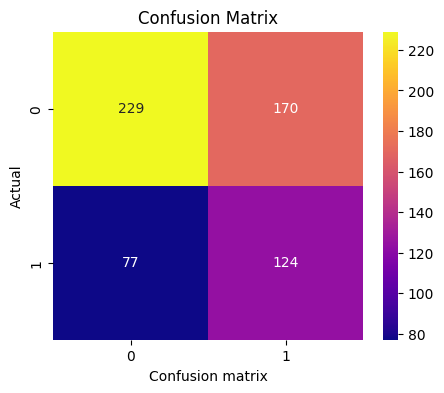

In [ ]:
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test,y_pred))

plt.show()
plt.figure(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='plasma')
plt.title('Confusion Matrix')
plt.xlabel('Confusion matrix')
plt.ylabel('Actual')
plt.show()